In [2]:
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [3]:
data_dir = Path("../data/raw")

X = pd.read_csv(
    data_dir / "secom.data",
    sep=r"\s+",
    header=None,
    na_values="NaN"
)

y = pd.read_csv(
    data_dir / "secom_labels.data",
    sep=r"\s+",
    header=None
)

missing_ratio = X.isna().mean()
high_missing_features = missing_ratio[missing_ratio >= 0.5].index

X_reduced = X.drop(columns=high_missing_features)
X_clean = X_reduced.fillna(X_reduced.median())

feature_variance = X_clean.var()
zero_variance_features = feature_variance[feature_variance == 0].index

X_clean = X_clean.drop(columns=zero_variance_features)

print("X_clean shape:", X_clean.shape)
print("y shape:", y.shape)
print("최종 결측치 개수:", X_clean.isna().sum().sum())

X_clean shape: (1567, 446)
y shape: (1567, 2)
최종 결측치 개수: 0


### SECOM feature들은 서로 값의 크기가 다릅니다.
예를 들어 어떤 feature는 3000대이고, 어떤 feature는 0.01대일 수 있습니다.
이 상태로 ML 모델에 넣으면 값이 큰 feature가 더 중요해 보이는 문제가 생길 수 있습니다.
그래서 표준화를 합니다.

표준화 = 각 feature를 평균 0, 표준편차 1이 되도록 변환
수식으로는:
표준화 값 = (원래 값 - 평균) / 표준편차
이렇게 하면 feature 간 단위 차이를 줄일 수 있습니다.

In [4]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X_clean)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=X_clean.columns,
    index=X_clean.index
)

print("X_scaled shape:", X_scaled.shape)

print("\n표준화 후 평균 예시:")
print(X_scaled.mean().head())

print("\n표준화 후 표준편차 예시:")
print(X_scaled.std().head())

X_scaled shape: (1567, 446)

표준화 후 평균 예시:
0    1.623320e-15
1   -5.073726e-15
2   -5.713362e-15
3   -1.269636e-16
4    0.000000e+00
dtype: float64

표준화 후 표준편차 예시:
0    1.000319
1    1.000319
2    1.000319
3    1.000319
4    1.000319
dtype: float64


개념 설명: Isolation Forest
Isolation Forest는 이상치를 찾는 머신러닝 방법입니다.
핵심 아이디어는:
정상 데이터는 비슷한 sample이 많아서 고립시키기 어렵다.
이상 데이터는 다른 sample들과 달라서 더 쉽게 고립된다.
즉, 여러 feature 조합을 봤을 때 혼자 동떨어진 sample을 이상으로 판단합니다.

In [5]:
fail_ratio = (y[0] == 1).mean()

iso_forest = IsolationForest(
    contamination=fail_ratio,
    random_state=42,
)

iso_forest.fit(X_scaled)

anomaly_prediction = iso_forest.predict(X_scaled)
anomaly_score = iso_forest.decision_function(X_scaled)

ml_result = pd.DataFrame({
    "label": y[0],
    "timestamp": y[1],
    "anomaly_prediction": anomaly_prediction,
    "anomaly_score": anomaly_score,
})

print("Fail ratio:", fail_ratio)

print("\nIsolation Forest prediction distribution:")
print(ml_result["anomaly_prediction"].value_counts())

print("\nPrediction label meaning:")
print(" 1 = normal")
print("-1 = anomaly")

Fail ratio: 0.06636885768985322

Isolation Forest prediction distribution:
anomaly_prediction
 1    1463
-1     104
Name: count, dtype: int64

Prediction label meaning:
 1 = normal
-1 = anomaly


In [6]:
ml_anomaly_mask = ml_result["anomaly_prediction"] == -1

total_anomalies = ml_anomaly_mask.sum()
fail_anomalies = ((ml_result["label"] == 1) & ml_anomaly_mask).sum()
pass_anomalies = ((ml_result["label"] == -1) & ml_anomaly_mask).sum()

total_fail = (ml_result["label"] == 1).sum()
total_pass = (ml_result["label"] == -1).sum()

fail_capture_rate = fail_anomalies / total_fail
false_alert_rate = pass_anomalies / total_pass
alert_fail_ratio = fail_anomalies / total_anomalies

print("ML anomaly total:", total_anomalies)
print("ML anomaly 중 fail:", fail_anomalies)
print("ML anomaly 중 pass:", pass_anomalies)

print("\nFail capture rate:", fail_capture_rate)
print("False alert rate:", false_alert_rate)
print("Alert fail ratio:", alert_fail_ratio)

ML anomaly total: 104
ML anomaly 중 fail: 14
ML anomaly 중 pass: 90

Fail capture rate: 0.1346153846153846
False alert rate: 0.06151742993848257
Alert fail ratio: 0.1346153846153846


In [7]:
score_thresholds = [0.05, 0.10, 0.15]

score_based_results = []

total_fail = (ml_result["label"] == 1).sum()
total_pass = (ml_result["label"] == -1).sum()

for ratio in score_thresholds:
    cutoff = ml_result["anomaly_score"].quantile(ratio)

    predicted_alert = ml_result["anomaly_score"] <= cutoff

    total_alerts = predicted_alert.sum()
    fail_alerts = ((ml_result["label"] == 1) & predicted_alert).sum()
    pass_alerts = ((ml_result["label"] == -1) & predicted_alert).sum()

    fail_capture_rate = fail_alerts / total_fail
    false_alert_rate = pass_alerts / total_pass
    alert_fail_ratio = fail_alerts / total_alerts if total_alerts > 0 else 0

    score_based_results.append({
        "alert_ratio": ratio,
        "score_cutoff": cutoff,
        "total_alerts": total_alerts,
        "fail_alerts": fail_alerts,
        "pass_alerts": pass_alerts,
        "fail_capture_rate": fail_capture_rate,
        "false_alert_rate": false_alert_rate,
        "alert_fail_ratio": alert_fail_ratio,
    })

score_based_df = pd.DataFrame(score_based_results)

print(score_based_df)

   alert_ratio  score_cutoff  total_alerts  fail_alerts  pass_alerts  \
0         0.05     -0.004133            79           11           68   
1         0.10      0.005726           157           20          137   
2         0.15      0.011426           235           28          207   

   fail_capture_rate  false_alert_rate  alert_fail_ratio  
0           0.105769          0.046480          0.139241  
1           0.192308          0.093643          0.127389  
2           0.269231          0.141490          0.119149  


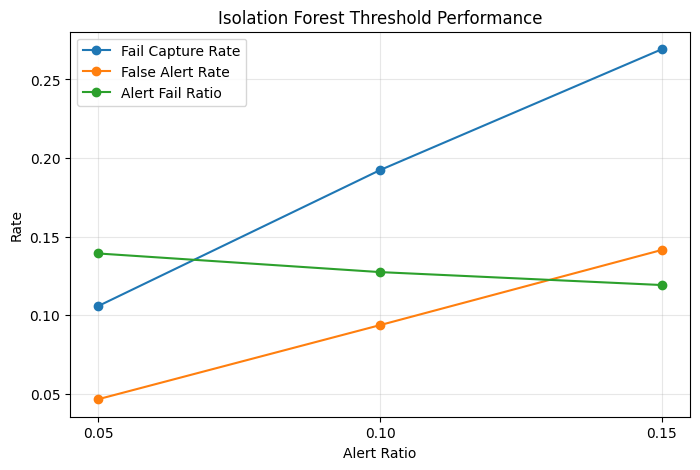

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    score_based_df["alert_ratio"],
    score_based_df["fail_capture_rate"],
    marker="o",
    label="Fail Capture Rate"
)

plt.plot(
    score_based_df["alert_ratio"],
    score_based_df["false_alert_rate"],
    marker="o",
    label="False Alert Rate"
)

plt.plot(
    score_based_df["alert_ratio"],
    score_based_df["alert_fail_ratio"],
    marker="o",
    label="Alert Fail Ratio"
)

plt.title("Isolation Forest Threshold Performance")
plt.xlabel("Alert Ratio")
plt.ylabel("Rate")
plt.xticks(score_based_df["alert_ratio"])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [10]:
comparison_df = pd.DataFrame([
    {
        "method": "SPC baseline",
        "threshold": "alert_count >= 1",
        "total_alerts": 92,
        "fail_alerts": 19,
        "pass_alerts": 73,
        "fail_capture_rate": 0.182692,
        "false_alert_rate": 0.049897,
        "alert_fail_ratio": 0.206522,
    },
    {
        "method": "Isolation Forest",
        "threshold": "score bottom 5%",
        "total_alerts": 79,
        "fail_alerts": 11,
        "pass_alerts": 68,
        "fail_capture_rate": 0.105769,
        "false_alert_rate": 0.046480,
        "alert_fail_ratio": 0.139241,
    },
])

print(comparison_df)

             method         threshold  total_alerts  fail_alerts  pass_alerts  \
0      SPC baseline  alert_count >= 1            92           19           73   
1  Isolation Forest   score bottom 5%            79           11           68   

   fail_capture_rate  false_alert_rate  alert_fail_ratio  
0           0.182692          0.049897          0.206522  
1           0.105769          0.046480          0.139241  


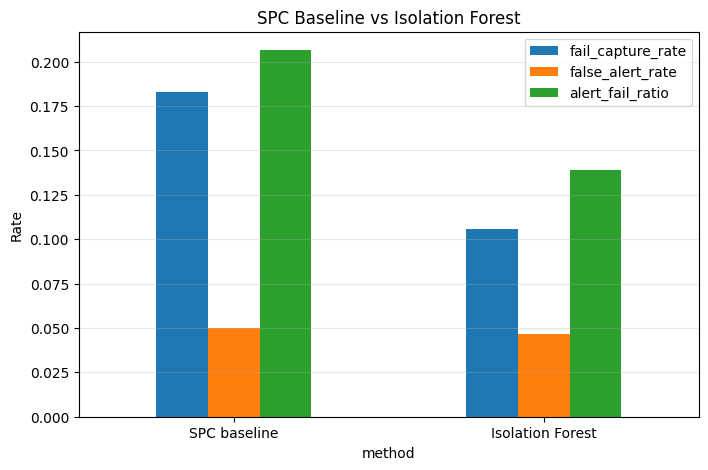

In [11]:
metrics = ["fail_capture_rate", "false_alert_rate", "alert_fail_ratio"]

comparison_plot_df = comparison_df.set_index("method")[metrics]

comparison_plot_df.plot(
    kind="bar",
    figsize=(8, 5),
)

plt.title("SPC Baseline vs Isolation Forest")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## ML Anomaly Detection Summary

This notebook applied Isolation Forest to the preprocessed SECOM dataset.

### Data Preparation

The raw SECOM feature table was preprocessed using the same logic as the previous steps:

1. Remove features with missing ratio greater than or equal to 50%
2. Fill remaining missing values with each feature's median
3. Remove zero-variance features

The final cleaned feature table had 1,567 samples and 446 features.

Before applying Isolation Forest, the features were standardized using `StandardScaler`.

### Isolation Forest Baseline

Isolation Forest was first trained with contamination set to the actual fail ratio.

- Fail ratio: 6.64%
- Predicted normal samples: 1,463
- Predicted anomaly samples: 104

The model predicted the same number of anomalies as the number of fail samples, but this does not mean it selected the same samples.

### Isolation Forest Result

Among the 104 anomaly samples selected by Isolation Forest:

- Fail samples: 14
- Pass samples: 90

Performance:

| Metric | Value |
|---|---:|
| Fail capture rate | 13.46% |
| False alert rate | 6.15% |
| Alert fail ratio | 13.46% |

### Score-Based Threshold Comparison

The anomaly score was used to compare different alert ratios.

| Alert Ratio | Total Alerts | Fail Alerts | Pass Alerts | Fail Capture Rate | False Alert Rate | Alert Fail Ratio |
|---:|---:|---:|---:|---:|---:|---:|
| 5% | 79 | 11 | 68 | 10.58% | 4.65% | 13.92% |
| 10% | 157 | 20 | 137 | 19.23% | 9.36% | 12.74% |
| 15% | 235 | 28 | 207 | 26.92% | 14.15% | 11.91% |

As the alert ratio increased, the model captured more fail samples but also produced more false alerts. The alert fail ratio decreased because more pass samples were included.

### SPC Baseline vs Isolation Forest

For a fair comparison, the Isolation Forest 5% threshold was compared with the SPC baseline because both had similar false alert rates.

| Method | Threshold | Total Alerts | Fail Alerts | Pass Alerts | Fail Capture Rate | False Alert Rate | Alert Fail Ratio |
|---|---|---:|---:|---:|---:|---:|---:|
| SPC baseline | alert count >= 1 | 92 | 19 | 73 | 18.27% | 4.99% | 20.65% |
| Isolation Forest | score bottom 5% | 79 | 11 | 68 | 10.58% | 4.65% | 13.92% |

### Interpretation

Under similar false alert rates, the SPC baseline captured more fail samples and had a higher alert fail ratio than Isolation Forest.

This means that, with the current basic settings, SPC was more effective than Isolation Forest for selecting high-risk samples in the SECOM dataset.

However, this does not mean machine learning is ineffective. Isolation Forest was only tested with basic settings. Future improvements may include parameter tuning, PCA-based anomaly detection, Local Outlier Factor, One-Class SVM, or combining SPC and ML alerts.

### Conclusion

The basic Isolation Forest model identified anomaly samples with a higher fail ratio than the overall dataset, but it did not outperform the SPC baseline.

The next step is to test additional anomaly detection methods or tune the Isolation Forest model.